# 03a — Criteo Uplift EDA: a randomized experiment in a box

Narrated exploration of the Criteo Uplift Modeling dataset (v2.1), for a reader who has never
touched it. The fitting notebook (`03_criteo.ipynb`) extracts uplift parameters; this one
establishes what the data is and what it can and cannot say. Read-only: no artifacts, no
mutations (spec Section 0, v0.4).

Provenance: HD — per the EDA-companion convention (P-006, INT-012).

## The one mental model that unlocks this dataset

**Each row is one user in a giant randomized incrementality test.** Criteo (an advertising
retargeting platform) randomly assigned users to be *eligible* for its ads (`treatment = 1`,
85%) or withheld from all of them (`treatment = 0`, 15%). Then it watched what the user did on
the advertiser's site: `visit` and `conversion`. Because assignment is random, the difference
in outcomes between arms is a *causal* effect of the advertising — not a correlation.

Two subtleties matter enormously:

- **Assignment is not exposure.** `exposure = 1` means the user was actually served an ad —
  which requires winning auctions for that user's impressions. Only a few percent of the
  treated arm was ever exposed; exposure is *post-treatment* (influenced by user behavior),
  so conditioning on it breaks the randomization. The clean causal contrast is
  treated-vs-control regardless of exposure — the **intent-to-treat (ITT)** effect.
- **The features are deliberately meaningless.** `f0..f11` are dense, anonymized numeric
  features with undocumented semantics. They exist to support *targeting models* (who benefits
  most from ads), not interpretation.

This maps one-to-one onto the design's marketing silo: the randomized holdout flag, a small
true uplift on application probability, and heterogeneity worth targeting (design Section 3.2
stage 4; decisions C5, C6).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
assert (ROOT / "pyproject.toml").exists()
d = pd.read_csv(ROOT / "data" / "raw" / "criteo" / "criteo-uplift-v2.1.csv.gz")
FEATURES = [f"f{i}" for i in range(12)]
print(f"rows: {len(d):,}   columns: {list(d.columns)}")


rows: 13,979,592   columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']


## 1. Sample rows and data dictionary

v2.1 is Criteo's 2021 re-release: ~13.98M users, 16 columns, no missing values anywhere.


In [2]:
d.sample(5, random_state=7)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
9842370,26.140824,10.059654,8.848786,4.679882,10.280525,4.115453,-3.993764,4.833815,3.790775,13.190056,5.300375,-0.168679,1,0,0,0
12002161,25.589651,10.059654,9.032961,4.679882,10.280525,4.115453,-5.987667,4.833815,3.872698,13.190056,5.300375,-0.168679,1,0,0,0
12060824,12.616365,10.059654,8.944798,4.679882,10.280525,4.115453,0.294443,4.833815,3.920995,13.190056,5.300375,-0.168679,1,0,0,0
1506726,18.428264,10.059654,8.602762,3.907662,10.280525,4.115453,-1.288207,4.833815,3.927254,21.416100,5.300375,-0.168679,1,0,0,0
3634799,22.243701,10.059654,8.214383,4.679882,10.280525,4.115453,-5.116672,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


In [3]:
DEFS = {
    **{f"f{i}": "Anonymized dense numeric feature; semantics deliberately undocumented "
                "(targeting signal only)" for i in range(12)},
    "treatment": "Randomized assignment: 1 = eligible for Criteo ads (85%), 0 = withheld (15%)",
    "conversion": "User converted on the advertiser's site within the attribution window",
    "visit": "User visited the advertiser's site within the window",
    "exposure": "User was actually served at least one ad (post-treatment; only possible in "
                "the treated arm)",
}
dictionary = pd.DataFrame(
    [(c, str(d[c].dtype), d[c].nunique(), int(d[c].isna().sum()), DEFS[c]) for c in d.columns],
    columns=["column", "dtype", "distinct", "nulls", "definition"])
pd.set_option("display.max_colwidth", 100)
dictionary


,column,dtype,distinct,nulls,definition
0,f0,float64,2181959,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
1,f1,float64,60,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
2,f2,float64,2051900,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
3,f3,float64,552,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
4,f4,float64,260,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
5,f5,float64,132,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
6,f6,float64,1645,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
7,f7,float64,622143,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
8,f8,float64,3743,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)
9,f9,float64,1594,0,Anonymized dense numeric feature; semantics deliberately undocumented (targeting signal only)


Note the `distinct` column: several features are near-continuous (millions of distinct values)
while others have heavy point masses (few distinct values dominating) — they behave like mixed
continuous/categorical encodings. `exposure` having *zero* positives in the control arm
(verified below) is by construction, not chance.


## 2. The experiment's headline numbers


In [4]:
arm = d.groupby("treatment").agg(n=("visit", "size"), visit_rate=("visit", "mean"),
                                  conversion_rate=("conversion", "mean"),
                                  exposure_rate=("exposure", "mean"))
print(arm.round(5).to_string())

t, c = d[d.treatment == 1], d[d.treatment == 0]
ate_c = t.conversion.mean() - c.conversion.mean()
se_c = np.sqrt(t.conversion.var()/len(t) + c.conversion.var()/len(c))
ate_v = t.visit.mean() - c.visit.mean()
print(f"\nITT effect on conversion: {ate_c*100:+.3f}pp  (95% CI +/- {1.96*se_c*100:.3f}pp)")
print(f"ITT effect on visit:      {ate_v*100:+.3f}pp")
print(f"relative conversion lift: {ate_c/c.conversion.mean():+.1%}")
print(f"exposure in control arm:  {int(c.exposure.sum())} rows (by construction)")
print(f"exposed share of treated: {t.exposure.mean():.2%}")
per_exposed = ate_c / t.exposure.mean()
print(f"\nDilution arithmetic: the ITT effect averages over ALL treated users, but only "
      f"{t.exposure.mean():.1%} ever saw an ad.\nIf the entire effect flows through exposure, "
      f"the per-exposed effect is roughly {ate_c*100:.3f}pp / {t.exposure.mean():.3f} "
      f"= {per_exposed*100:.1f}pp — two orders of magnitude larger than the ITT number.\n"
      f"(A back-of-envelope only: exposure is post-treatment, so this is not a clean causal "
      f"quantity.)")


                  n  visit_rate  conversion_rate  exposure_rate
treatment                                                      
0           2096937     0.03820          0.00194        0.00000
1          11882655     0.04854          0.00309        0.03604



ITT effect on conversion: +0.115pp  (95% CI +/- 0.007pp)
ITT effect on visit:      +1.034pp
relative conversion lift: +59.4%
exposure in control arm:  0 rows (by construction)
exposed share of treated: 3.60%

Dilution arithmetic: the ITT effect averages over ALL treated users, but only 3.6% ever saw an ad.
If the entire effect flows through exposure, the per-exposed effect is roughly 0.115pp / 0.036 = 3.2pp — two orders of magnitude larger than the ITT number.
(A back-of-envelope only: exposure is post-treatment, so this is not a clean causal quantity.)


Semantics worth absorbing:

- **The absolute effect is tiny (+0.1pp) while the relative effect is large (~+59%).** Real
  marketing uplift lives at this scale — this is precisely why the design calibrates the
  simulated marketing effect to Criteo (C6) instead of inventing a flattering number.
- **Conversion is severely rare (0.2-0.3%).** Any model on this data fights class imbalance;
  naive accuracy is meaningless.
- **The 15% holdout is the price of knowledge**: Criteo gave up ad revenue on 2.1M users to
  measure causality. The marketplace analog (design Section 7): you cannot know campaign ROI
  without withholding — which is exactly what the simulated marketing silo's holdout flag is.


## 3. Randomization check (covariate balance)

If assignment is truly random, feature distributions should be indistinguishable between arms.
The standard diagnostic is the standardized mean difference (SMD); the conventional threshold is |SMD| < 0.1, below which arms are considered
balanced.


In [5]:
smd = ((t[FEATURES].mean() - c[FEATURES].mean())
       / d[FEATURES].std()).abs().sort_values(ascending=False)
print(smd.round(4).to_string())
print(f"\nmax |SMD| = {smd.max():.4f} -> randomization holds; treated-vs-control differences "
      "in outcomes are causal, not compositional.")


f3     0.0474
f6     0.0400
f5     0.0295
f9     0.0237
f1     0.0229
f8     0.0222
f7     0.0210
f10    0.0105
f4     0.0079
f0     0.0069
f2     0.0063
f11    0.0051

max |SMD| = 0.0474 -> randomization holds; treated-vs-control differences in outcomes are causal, not compositional.


## 4. Collinearity among the features


strongest feature-feature correlations:
f9   f8   -0.750
f7   f5   -0.746
f11  f4   -0.676
f10  f4    0.661
f5   f1   -0.575
f6   f3    0.549
f2   f0   -0.514
f8   f4   -0.411


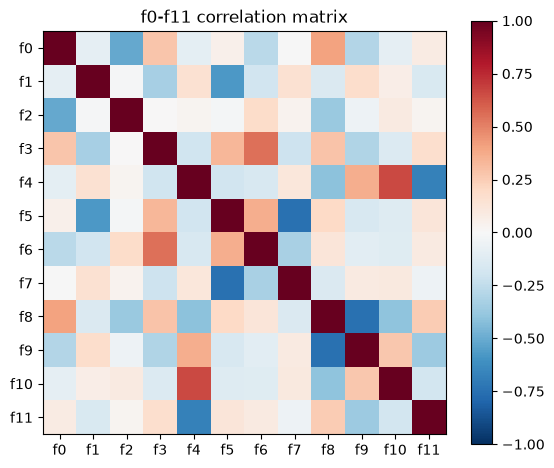

In [6]:
corr = d[FEATURES].sample(2_000_000, random_state=42).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
pairs = corr.where(~mask).stack().sort_values(key=abs, ascending=False)
print("strongest feature-feature correlations:")
print(pairs.head(8).round(3).to_string())
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(12), FEATURES); ax.set_yticks(range(12), FEATURES)
fig.colorbar(im); ax.set_title("f0-f11 correlation matrix")
plt.show()


## 5. Business implications for Tributary, and declared assumptions

- **The holdout flag is sacred.** The simulated marketing silo carries a randomized holdout
  exactly like `treatment`; every uplift claim in Phase 5 (Model 4) is validated against it.
- **Uplift heterogeneity is the economic point**: the average effect is +0.1pp, but if some
  segments carry 3-5x the average (C6), targeting spend at them is where money is made. The
  fitting notebook measures this spread and ports it into segment multipliers.
- **ITT discipline transfers**: the marketplace's message logs will also have post-treatment
  events (opens, clicks); the simulated experiment's ground truth is assignment, not
  engagement.

Declared assumptions in this analysis:

1. Feature semantics are unknowable by design; we use `f0..f11` only to measure heterogeneity
   *spread*, never to interpret drivers.
2. The per-exposed effect computed above is illustrative arithmetic, not a causal estimate
   (exposure is post-treatment).
3. v2.1 is the authoritative release (the earlier ~25M-row v1 had a different sampling of the
   control arm); rates here are v2.1 rates.

Related: `03_criteo.ipynb` (the fits), decisions C5, C6 in `meta/logs/decisions.md`.
